## Designing Production-Grade RAG Systems

Retrieval-Augmented Generation (RAG) is the architectural pattern that separates production AI systems from unreliable demos. This deck walks you through every critical layer—chunking, embeddings, vector search, context management, and evaluation—so you can build AI systems that are grounded, traceable, and production-ready.

* **Architecture**: End-to-end pipeline design with labeled components and real data flow.


* **Retrieval**: Embeddings, vector databases, and semantic search in production.


* **Evaluation**: Grounding, citations, anti-patterns, and quality rubrics.


* **Production**: From Jupyter notebook demos to deployable, scalable AI services.

## Why LLMs Hallucinate

* **Core Mechanism**: Large language models generate text by predicting statistically likely continuations of a prompt rather than querying verified facts.


* **Reliability Impact**: This makes them fluent but fundamentally unreliable for knowledge-sensitive tasks.



---

### Comparison: Retrieval vs. No Retrieval

* **Without Retrieval (Hallucinated)**:
* The model guesses based on training patterns, resulting in completely fabricated answers.


* *Example*: Responding to an inquiry about international order refunds with a fabricated policy estimate.




* **With Retrieval (Grounded)**:
* The model provides cited, traceable, and accurate responses grounded in retrieved context documents.


* *Example*: Citing specific policy sections (e.g., §4.2) to deliver exact terms like store credit limitations within 14 days.

## What RAG Solves in Production

Retrieval-Augmented Generation closes the gap between a model's static training knowledge and the dynamic, private, or specialized data your application depends on. By grounding every response in retrieved context, RAG dramatically reduces hallucinations and unlocks enterprise-grade trust.

---

### LLM-Only System vs. RAG-Powered System

* **LLM-Only System**:
* No access to private or recent data.


* Hallucinations are unpredictable.


* No citations or source traceability.


* Fails on domain-specific queries.




* **RAG-Powered System**:
* Retrieves from live, proprietary knowledge.


* Responses grounded in real documents.


* Source citations included in output.


* Scales to any domain with new data.

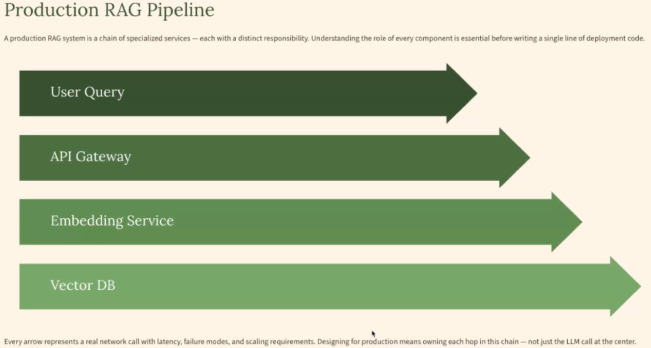

## Chunking Strategies: Good vs. Bad

Chunking is how you split source documents into retrievable units. Naive chunking—fixed character counts with no semantic awareness—is one of the most common causes of poor retrieval quality. The chunk boundary determines whether the model gets enough context to answer correctly.

---

### Naive / Oversized Chunking vs. Semantic / Structured Chunking

* **Naive / Oversized Chunking**:
* Fixed 2,000-character splits regardless of content.


* Sentences and paragraphs cut mid-thought.


* Chunks contain multiple unrelated topics.


* Embeddings average out—low retrieval precision.


* Retrieved chunk confuses the LLM with noise.




* **Semantic / Structured Chunking**:
* Split on paragraph, section, or sentence boundaries.


* Each chunk covers exactly one idea or concept.


* Overlap window preserves cross-boundary context.


* Embedding is dense and topically focused.


* Retrieved chunk maps cleanly to the user's query.





> **Rule of thumb**: Chunk size should match the granularity of the questions users will ask.
> 
>

## Embeddings & Semantic Search

An embedding model transforms text—a query, a sentence, a document chunk—into a high-dimensional vector. Semantically similar texts land near each other in this vector space, enabling similarity search that goes far beyond keyword matching. This is the mathematical foundation of all modern RAG systems.

---

### How Semantic Search Works

* **01. Encode**: Both documents and queries are passed through the same embedding model, producing comparable vectors.


* **02. Index**: Document vectors are stored and indexed in a vector database using ANN (Approximate Nearest Neighbor) structures.


* **03. Retrieve**: At query time, top-K nearest vectors are returned—these are your most semantically relevant chunks.

## Role of Vector Databases in AI Systems

Vector databases are purpose-built for one job: storing millions of high-dimensional embeddings and returning the most similar ones in milliseconds. They are not a nice-to-have—they are the core retrieval infrastructure that makes RAG possible at scale. Pinecone, Weaviate, Qdrant, and pgvector are common production choices.

---

### Core Capabilities

* **Persistent Embedding Store**: Stores all pre-computed chunk embeddings with associated metadata, enabling fast recall without re-encoding documents at query time.


* **ANN-Powered Similarity Search**: Uses index structures like HNSW or IVF to return top-$K$ nearest neighbors in sub-$50\text{ms}$—even across tens of millions of vectors.


* **Metadata Filtering**: Combines vector similarity with structured filters (e.g., by tenant, date, document type) to scope retrieval precisely and avoid cross-tenant data leakage.


* **Horizontal Scalability**: Distributes index shards across nodes to handle growing corpora and concurrent query loads without degrading latency.

## Context Window Management

Every LLM has a finite context window—a hard limit on how many tokens it can process in a single call. Stuffing it with too many retrieved chunks does not improve answers; it degrades them by introducing noise, diluting signal, and inflating latency and cost.

---

### Context Window Budget Breakdown

* **System prompt**: $\sim 300\text{ tokens}$

* **Retrieved chunks (top-3)**: $\sim 900\text{ tokens}$

* **User query + history**: $\sim 200\text{ tokens}$

* **Reserved for output**: $\sim 600\text{ tokens}$

* **Total used**: $\sim 2,000 / 4,096\text{ tokens}$ $\checkmark$


---

### Common Mistakes

* Passing all retrieved chunks without ranking or truncation


* No maximum token guard on individual chunks


* Forgetting to account for system prompt size


* Not reserving tokens for the model's output



> **Best practice**: Rank chunks by relevance score. Admit the top-$K$ that fit within your reserved budget, then stop.
> 
>

## Evaluating RAG Outputs

You cannot ship what you cannot measure. RAG evaluation must cover three orthogonal dimensions: whether the retrieved context was relevant, whether the answer is grounded in that context, and whether the answer fully addresses the user's question. You can automate this with frameworks like RAGAS or LLM-as-a-judge.

---

### Four Dimensions of RAG Evaluation

* **1. Context Relevance**:
* Evaluates whether the retrieved chunks are actually related to the user's query.


* Scored using embedding cosine similarity or an LLM judge.


* Low scores indicate underlying chunking or retrieval problems.




* **2. Faithfulness / Grounding**:
* Checks whether every claim in the response traces back directly to the retrieved context.


* Hallucinated statements that cannot be cited represent a direct faithfulness failure.




* **3. Answer Completeness**:
* Measures whether the response fully addresses all aspects of the user's query.


* Partial answers that omit key retrieved facts will score poorly here.




* **4. Citation Traceability**:
* Determines if every factual claim can be successfully linked back to a specific source chunk and document.


* This is an essential requirement for enterprise trust and system debugging.

## Common RAG Anti-Patterns

Most RAG failures in production are not model failures—they are architectural mistakes made during system design. These anti-patterns are well-documented and entirely avoidable once you know what to look for.

---

### Four Major RAG Anti-Patterns

* **Document Stuffing**:
* Passing full source documents instead of semantically chunked units.


* The embedding averages out to noise, retrieval precision collapses, and the LLM context window overflows.




* **No Retrieval Filtering**:
* Retrieving globally across all documents with no metadata scoping.


* In multi-tenant or multi-domain systems, this causes cross-contamination of context and security violations.




* **No Evaluation Pipeline**:
* Shipping RAG with zero automated quality checks.


* Without a faithfulness and relevance eval loop, regressions caused by new data or model updates are invisible until users complain.




* **Single-Stage Retrieval Only**:
* Relying on a single vector similarity pass with no re-ranking step.


* Hybrid retrieval (BM25 + dense) plus a cross-encoder reranker significantly improves top-$K$ precision.

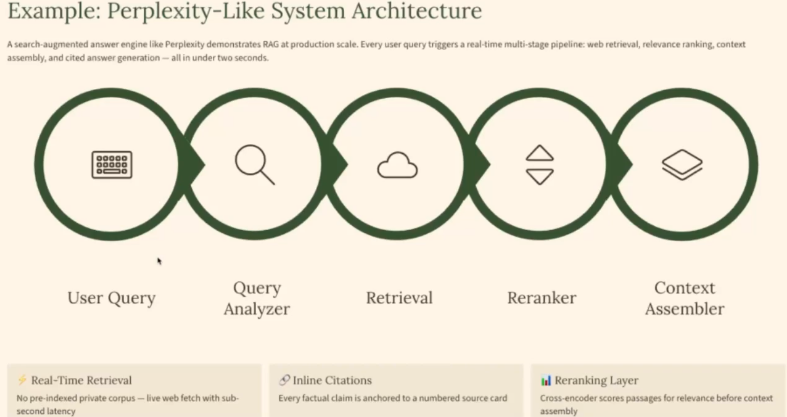

## From RAG Demos to RAG Systems

Running a RAG notebook accounts for only 10% of the work, while the remaining 90% involves the engineering required to make the system observable, scalable, secure, and continuously improving. Most teams underestimate this gap until they encounter production incidents.

---

### Evolutionary Stages of a RAG System

* **Demo (Notebook)**:
* Built with tools like LangChain, a local FAISS index, and a single PDF.


* Works on a local laptop for a single query with no authentication, error handling, or logging.




* **Service (Deployed API)**:
* Features containerized embedding, retrieval, and generation services behind an API gateway with authentication.


* Incorporates asynchronous queuing, observability with traces and latency metrics, and a managed vector database.




* **Product (Production System)**:
* Implements a continuous evaluation pipeline and automated re-indexing upon data updates.


* Ensures multi-tenant isolation, per-query cost tracking, and active feedback loops from real users to optimize retrieval quality.